# Analysing Absenteeism in the Workplace

# Extract, Transform, Load(EDA)

In [3]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [4]:
# Reading files
absent = pd.read_csv("Absent_Data.csv")
compensation = pd.read_csv("compensation.csv")
reasons = pd.read_csv("Reasons.csv")

In [5]:
# Exploring data
absent.info()
compensation.info()
reasons.info()

absent.head()
compensation.head()
reasons.head()

absent.columns
compensation.columns
reasons.columns

# Checking NaN values
absent.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   ID                               740 non-null    int64 
 1   Reason for absence               740 non-null    int64 
 2   Month of absence                 740 non-null    int64 
 3   Day of the week                  740 non-null    int64 
 4   Seasons                          740 non-null    int64 
 5   Transportation expense           740 non-null    int64 
 6   Distance from Residence to Work  740 non-null    int64 
 7   Service time                     740 non-null    int64 
 8   Age                              740 non-null    int64 
 9   Work load Average/day            740 non-null    object
 10  Hit target                       740 non-null    int64 
 11  Disciplinary failure             740 non-null    int64 
 12  Education                        740

ID                                 0
Reason for absence                 0
Month of absence                   0
Day of the week                    0
Seasons                            0
Transportation expense             0
Distance from Residence to Work    0
Service time                       0
Age                                0
Work load Average/day              0
Hit target                         0
Disciplinary failure               0
Education                          0
Son                                0
Social drinker                     0
Social smoker                      0
Pet                                0
Weight                             0
Height                             0
Body mass index                    0
Absenteeism time in hours          0
dtype: int64

In [6]:
# Function to standardize column names
def clean_columns(df):
    df.columns = (
        df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ", "_")
            .str.replace("/", "_per_")
    )
    return df

# Applying function to columns
clean_columns(absent)
clean_columns(compensation)
clean_columns(reasons)

# Checking output
print(absent.columns)
print(compensation.columns)
print(reasons.columns)

Index(['id', 'reason_for_absence', 'month_of_absence', 'day_of_the_week',
       'seasons', 'transportation_expense', 'distance_from_residence_to_work',
       'service_time', 'age', 'work_load_average_per_day', 'hit_target',
       'disciplinary_failure', 'education', 'son', 'social_drinker',
       'social_smoker', 'pet', 'weight', 'height', 'body_mass_index',
       'absenteeism_time_in_hours'],
      dtype='object')
Index(['id', 'comp_per_hr'], dtype='object')
Index(['number', 'reason'], dtype='object')


In [7]:
# Function to check categorical values 
def count_objects(df):
    for col in df.select_dtypes("object").columns:
        print(df[col].value_counts())
        print()

# Function to check top 5 and bottom 5 for wierd values
def top_bot_val(df):
    for col in df.columns:
        string = df[col].sort_values().unique()
        top5 = string[:5]
        bot5 = string[-5:]
        print(str(col) + " : " + str(top5) + " ; " + str(bot5) + "\n")

# Checking categorical and extreme values
count_objects(absent)
count_objects(compensation)
count_objects(reasons)

top_bot_val(absent)
top_bot_val(compensation)
top_bot_val(reasons)

work_load_average_per_day
222,196    36
264,249    33
237,656    32
343,253    29
265,017    28
284,853    25
308,593    24
268,519    23
244,387    22
284,031    22
241,476    22
205,917    21
251,818    21
246,288    20
326,452    20
230,290    20
294,217    19
239,554    19
275,089    19
253,957    19
236,629    19
253,465    18
302,585    18
306,345    18
265,615    18
378,884    16
377,550    16
246,074    16
275,312    16
261,306    15
313,532    15
280,549    15
249,797    15
239,409    13
264,604    12
261,756    12
330,061    11
271,219     3
Name: count, dtype: int64

reason
Unkown                                                                                                 1
Certain infectious and parasitic diseases                                                              1
Neoplasms                                                                                              1
Diseases of the blood and blood-forming organs and certain disorders involving the immune mec

In [8]:
# Remove quotes from work load and convert to number data type
absent["work_load_average_per_day"] = absent["work_load_average_per_day"].str.replace(",", "")
absent["work_load_average_per_day"] = absent["work_load_average_per_day"].astype(int)
absent["work_load_average_per_day"].head()

# Check month of absence = 0 data and convert to suitable month number
absent[absent["month_of_absence"] == 0]
absent.loc[absent["month_of_absence"] == 0, "month_of_absence"] = 1

# Adding season column
conditions = [
    absent["month_of_absence"].isin([12, 1, 2]),
    absent["month_of_absence"].isin([3, 4, 5]),
    absent["month_of_absence"].isin([6, 7, 8]),
    absent["month_of_absence"].isin([9, 10, 11])
]
choices = ["Winter", "Spring", "Summer", "Fall"]
absent["season_name"] = np.select(conditions, choices, default="Winter")

# Adding bmi category
conditions = [
    absent["body_mass_index"] < 18.5,
    absent["body_mass_index"].between(18.5, 25),
    absent["body_mass_index"].between(25, 30),
    absent["body_mass_index"] > 18.5
]
choices = ["Underweight", "Healthy", "Overweight", "Obese"]
absent["bmi_category"] = np.select(conditions, choices, default="Unknown")

# Converting reasons to proper format
reasons["reason"] = reasons["reason"].str.title()

# Changing reasons value from unkown
reasons.loc[reasons["reason"] == "Unkown", "reason"] = "Unknown"

In [9]:
# Merging absent and compensation
merge1 = absent.merge(
    compensation,
    how = "inner",
    on="id",
    validate="1:1"
)

# merging 1st merge with reasons
merge2 = merge1.merge(
    reasons,
    how="inner",
    left_on="reason_for_absence",
    right_on="number",
    indicator=True,
    validate="m:1"
)

# Exploring final merge
merge2.columns
merge2.head()

,id,reason_for_absence,month_of_absence,day_of_the_week,seasons,transportation_expense,distance_from_residence_to_work,service_time,age,work_load_average_per_day,...,weight,height,body_mass_index,absenteeism_time_in_hours,season_name,bmi_category,comp_per_hr,number,reason,_merge
0,1,26,7,3,1,289,36,13,33,239554,...,90,172,30,4,Summer,Overweight,35,26,Unjustified Absence,both
1,2,0,7,3,1,118,13,18,50,239554,...,98,178,31,0,Summer,Obese,49,0,Unknown,both
2,3,23,7,4,1,179,51,18,38,239554,...,89,170,31,2,Summer,Obese,47,23,Medical Consultation,both
3,4,7,7,5,1,279,5,14,39,239554,...,68,168,24,4,Summer,Healthy,51,7,Diseases Of The Eye And Adnexa,both
4,5,23,7,5,1,289,36,13,33,239554,...,90,172,30,2,Summer,Overweight,25,23,Medical Consultation,both


In [10]:
# Selecting relevant data for analysis
final_absent = merge2.loc[:,["id", "reason", 'body_mass_index', 'bmi_category', "season_name",
                             'month_of_absence', 'day_of_the_week', 
                             'transportation_expense', 'distance_from_residence_to_work',
                             'education', 'son', 'social_drinker', 'social_smoker', 'pet',
                             'disciplinary_failure', 'age', 'absenteeism_time_in_hours', 'comp_per_hr']]
final_absent.head() # Exploring final data

,id,reason,body_mass_index,bmi_category,season_name,month_of_absence,day_of_the_week,transportation_expense,distance_from_residence_to_work,education,son,social_drinker,social_smoker,pet,disciplinary_failure,age,absenteeism_time_in_hours,comp_per_hr
0,1,Unjustified Absence,30,Overweight,Summer,7,3,289,36,1,2,1,0,1,0,33,4,35
1,2,Unknown,31,Obese,Summer,7,3,118,13,1,1,1,0,0,1,50,0,49
2,3,Medical Consultation,31,Obese,Summer,7,4,179,51,1,0,1,0,0,0,38,2,47
3,4,Diseases Of The Eye And Adnexa,24,Healthy,Summer,7,5,279,5,1,2,1,1,0,0,39,4,51
4,5,Medical Consultation,30,Overweight,Summer,7,5,289,36,1,2,1,0,1,0,33,2,25


# Finding Healthy Employees and Compensation per Year for Healthy Employees based on Company Budget

In [11]:
# Finding healthiest employees for the bonus
print(
    final_absent[
        (final_absent["social_drinker"] == 0) &
        (final_absent["social_smoker"] == 0) &
        (final_absent["body_mass_index"].between(19,25)) &
        (final_absent["absenteeism_time_in_hours"] < merge2["absenteeism_time_in_hours"].mean() )
    ].sort_values(["body_mass_index", "absenteeism_time_in_hours", "id"], ascending = [False, True, True]).head(10)
)

      id                            reason  body_mass_index bmi_category  \
214  215                           Unknown               25      Healthy   
325  326                           Unknown               25      Healthy   
715  716                           Unknown               25      Healthy   
739  740                           Unknown               25      Healthy   
152  153             Medical Consultation                25      Healthy   
458  459  Diseases Of The Digestive System               25      Healthy   
617  618           Laboratory Examination                25      Healthy   
676  677              Dental Consultation                25      Healthy   
698  699             Medical Consultation                25      Healthy   
508  509  Diseases Of The Digestive System               25      Healthy   

    season_name  month_of_absence  day_of_the_week  transportation_expense  \
214      Spring                 5                4                     330   
325    

In [12]:
# Defining compensation per year given total budget
def comp_per_year(budget):
    workers = final_absent[final_absent["social_smoker"] == 0]["id"].count()
    return print("Total compensation per employee is " + str(round(budget/workers,2)))
comp_per_year(983221)

Total compensation per employee is 1433.27


# Exploratory Data Analysis (EDA)

## Part 1 - Checking KPIs

In [13]:
# EDA KPI
print("No of employees: " + str(final_absent['id'].count()))
print("Average age: " + str(round(final_absent["age"].mean())) + " Years")
print("Total Absent Time: " + str(final_absent["absenteeism_time_in_hours"].sum()) + " Hours")
print("Average time absent per employee: " +
      str(round(final_absent["absenteeism_time_in_hours"].mean(),2)) + " Hours")
print("Highest Hours Absent: " + str(final_absent["absenteeism_time_in_hours"].max()) + " Hours")
total_emp = final_absent['id'].count()
tot_drink_smoke = final_absent[
                        (final_absent["social_smoker"] == 1) |
                        (final_absent["social_drinker"] == 1)
]["id"].count()
print("Total drinker of smoker: " + str(round(tot_drink_smoke*100/total_emp,2)) + " %")

No of employees: 740
Average age: 36 Years
Total Absent Time: 5124 Hours
Average time absent per employee: 6.92 Hours
Highest Hours Absent: 120 Hours
Total drinker of smoker: 61.35 %


## Part 2 - Absenteeism Overview

In [14]:
# Top Reasons for being Absent
print(final_absent["reason"].value_counts(sort = True).head(10))

reason
Medical Consultation                                                   149
Dental Consultation                                                    112
Physiotherapy                                                           69
Diseases Of The Musculoskeletal System And Connective Tissue            55
Unknown                                                                 43
Injury, Poisoning And Certain Other Consequences Of External Causes     40
Patient Follow-Up                                                       38
Unjustified Absence                                                     33
Laboratory Examination                                                  31
Diseases Of The Digestive System                                        26
Name: count, dtype: int64


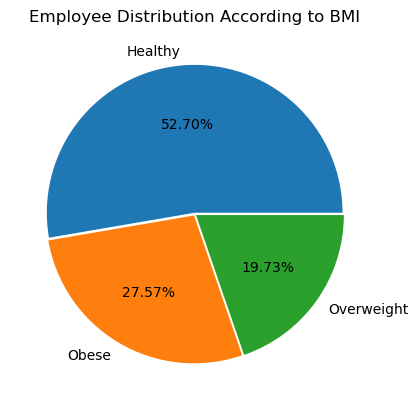

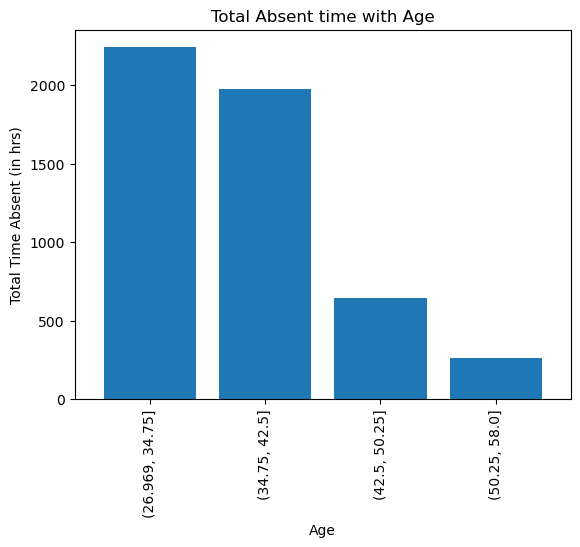

<Figure size 640x480 with 0 Axes>

In [15]:
# Employee Distribution According to BMI - piechart
final_absent["bmi_category"].value_counts().plot(
    kind = "pie",
    autopct = "%1.2f%%",
    ylabel = "",
    startangle = 0,
    explode = [0.01, 0.01, 0.01]
)
plt.title("Employee Distribution According to BMI")
plt.show()
plt.clf()

# Total Absent time with age - bar chart
bins = pd.cut(final_absent["age"], bins = 4) 
grouped = final_absent.groupby(bins, observed= False)["absenteeism_time_in_hours"].sum()
grouped.plot(kind = "bar", width = 0.8)
plt.xlabel("Age")
plt.ylabel("Total Time Absent (in hrs)")
plt.title("Total Absent time with Age")
plt.show()
plt.clf()

In [16]:
# Defining functions to draw time-series graphs

def time_series(data, time_type, y):
    if time_type not in ["Year", "Week"]:
        raise ValueError("time_type must be 'Year' or 'Week'")
    
    if time_type == "Year":
        x = "month_of_absence"
        ticks = sorted(data[x].unique())
        labels = [calendar.month_abbr[m] for m in ticks]
    else:
        x = "day_of_the_week"
        ticks = sorted(data[x].unique())
        labels = [calendar.day_abbr[m-2] for m in ticks]

    # Plotting graphs
    sns.lineplot(data = data,
                 x = x,
                 y = y,
                 estimator = len,
                 errorbar = None
    )

    # Customization
    plt.xticks(ticks = ticks, labels = labels)
    plt.title(f"Total Employees Absent During the {time_type}")
    plt.xlabel("")
    plt.ylabel("No of Employees")
    plt.show()

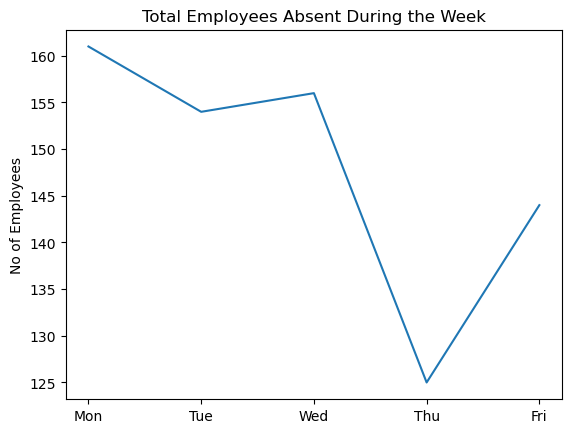

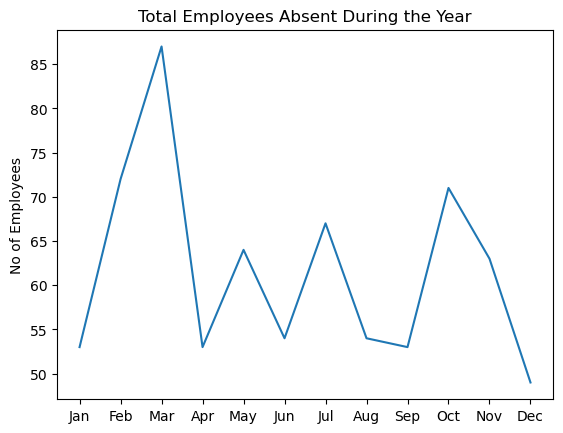

In [17]:
# Plotting time-series graphs
time_series(final_absent, "Week", "id")
time_series(final_absent, "Year", "id")

## Part 3 - Analysing Absenteeism Factors

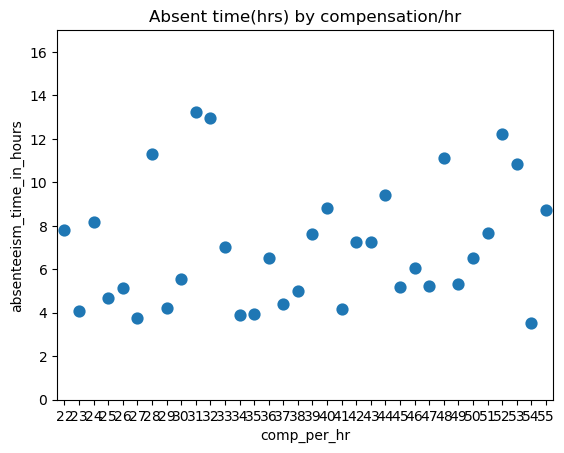

<Figure size 640x480 with 0 Axes>

In [18]:
# Absent time(hrs) by compensation/hr - scatter plot

# Finding outliers
sns.boxplot(data = final_absent, x = "comp_per_hr") # None
sns.boxplot(data = final_absent, x = "absenteeism_time_in_hours") # Outliers from ~ 20
plt.clf()

# Finding outer outlier
seventy_five = final_absent["absenteeism_time_in_hours"].quantile(0.75)
twenty_five = final_absent["absenteeism_time_in_hours"].quantile(0.25)
IQR = seventy_five - twenty_five
outerOutliner = 1.5*IQR + seventy_five # exact 17

# Plotting final
sns.pointplot(data = final_absent, x = "comp_per_hr", y = "absenteeism_time_in_hours", estimator= np.mean, errorbar= None, linestyles="")
plt.ylim(0,outerOutliner)

plt.title("Absent time(hrs) by compensation/hr")
plt.show()
plt.clf()

In [19]:
# Function to draw bar/columns graphs
def draw_bars(data, x, y, legend, type):

    if type == "bar":
        xf = y
        yf = x
    else:
        xf = x
        yf = y

    sns.barplot(data = data, x = xf, y = yf, estimator=np.sum, errorbar=None, hue = legend )
    
    if type == "bar":
        plt.title(f"Absent time(hrs) by {yf}")
    else:
        plt.title(f"Absent time(hrs) by {xf}")
    
    plt.show()

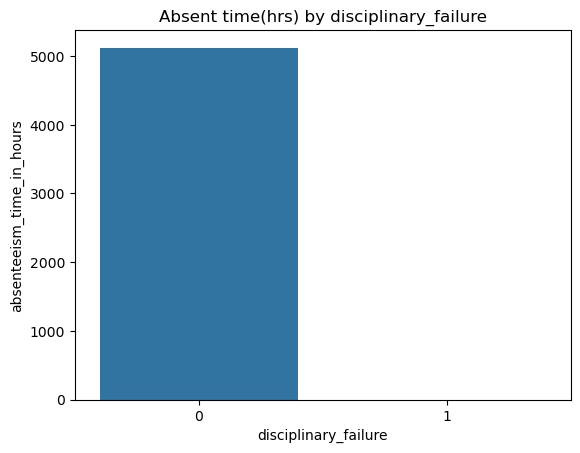

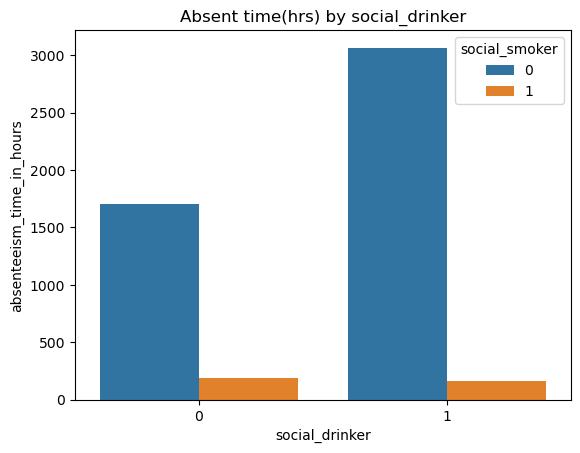

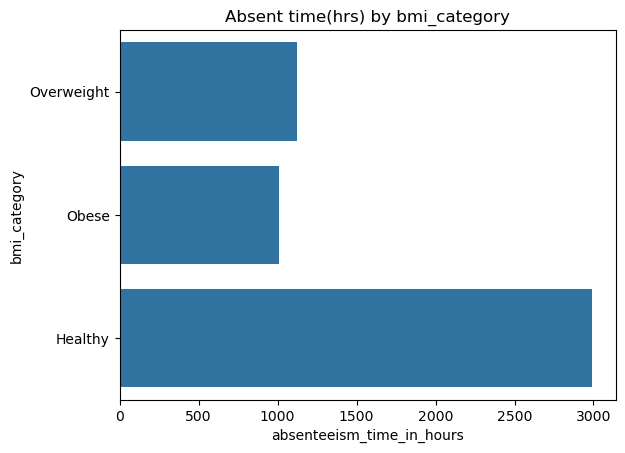

In [20]:
# Drawing bar/column graphs
draw_bars(final_absent, "disciplinary_failure", "absenteeism_time_in_hours",None,None)
draw_bars(final_absent, "social_drinker", "absenteeism_time_in_hours","social_smoker",None)
draw_bars(final_absent, "bmi_category", "absenteeism_time_in_hours",None,"bar")

In [21]:
# Function to draw donut charts
def draw_donut(data, group, values):
    df = data.groupby(group)[values].sum()

    if group == "education":
        target = "Degrees"
    elif group == "son":
        target = "Children"
    else:
        target = "Pets"
    
    plt.pie(df, autopct="%1.2f%%", 
            startangle= 90, wedgeprops={"width":0.4},
            pctdistance=0.75, textprops={'fontsize':10, 'color': 'black'})
    plt.legend(df.index, title = f"No of {target}", loc = "best", bbox_to_anchor = (1, 0.5))
    plt.title(f"Distribution of total hrs absent by Total {target}")
    plt.tight_layout()
    plt.show()

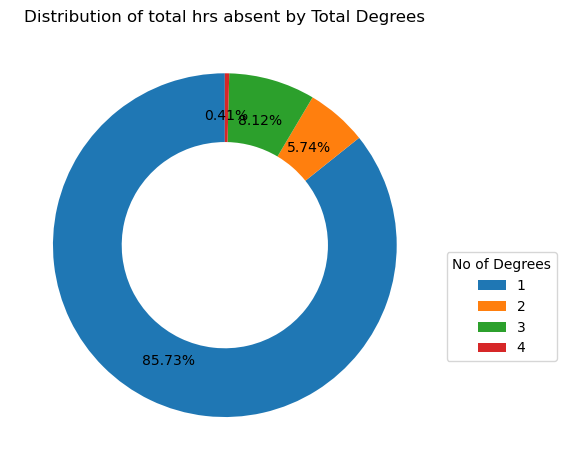

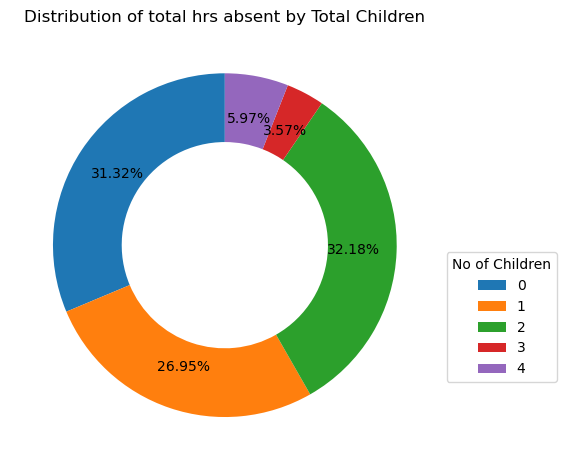

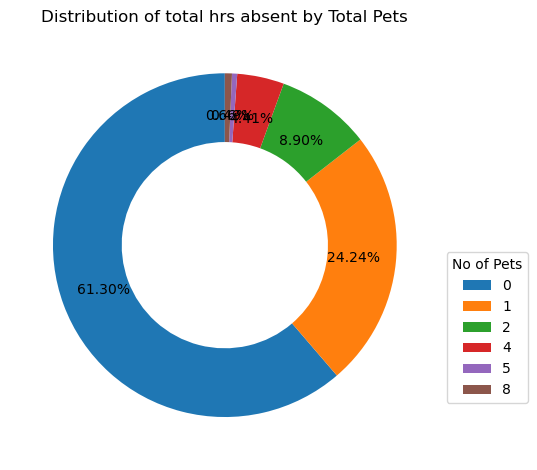

In [22]:
# Drawing donut charts
draw_donut(final_absent, "education", "absenteeism_time_in_hours")
draw_donut(final_absent, "son", "absenteeism_time_in_hours")
draw_donut(final_absent, "pet", "absenteeism_time_in_hours")

# Final Insights
1. Non-Smokers are eligible for a wage increase of approx $1433.
2. March sees the highest number of absentees; Thursdays the lowest.
3. Over 50% of employees taking leave are in the healthy BMI range.
4. Significant absent hours come from the 27-34 age group.
5. Medical and dental consultations make up majority of the leaves.
6. There is a slight positive correlation between compensation/hour and absent hours
7. No one who had a disciplinary failure took leave
8. Employees who drink but do not smoke had the highest absent hours.

# Thank you!